# Multimodal RAG for video analytics with LlamaIndex

Constructing a RAG pipeline for text is relatively straightforward, thanks to the tools developed for parsing, indexing, and retrieving text data. However, adapting RAG models for video content presents a greater challenge. Videos combine visual, auditory, and textual elements, requiring more processing power and sophisticated video pipelines.

To build a truly multimodal search for videos, you need to work with different modalities of a video like spoken content, visual. In this notebook, we showcase a Multimodal RAG pipeline designed for video analytics. It utilizes Whisper model to convert spoken content to text, CLIP model to generate multimodal embeddings, and Vision Language model (VLM) to process retrieved images and text messages. The following picture illustrates how this pipeline is working.

![Multimodal RAG](https://github.com/user-attachments/assets/baef4914-5c07-432c-9363-1a0cb5944b09)

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Convert and Compress models](#Convert-and-Compress-models)
    - [ASR model](#ASR-model)
    - [CLIP model](#CLIP-model)
    - [VLM model](#VLM-model)
- [Download and process video](#Download-and-process-video)
    - [Initialize ASR](#Initialize-ASR)
- [Create the multi-modal index](#Create-the-multi-modal-index)
    - [Initialize CLIP](#Initialize-CLIP)
- [Search text and image embeddings](#Search-text-and-image-embeddings)
- [Generate final response using VLM](#Generate-final-response-using-VLM)
    - [Set the RAG prompt template](#Set-the-RAG-prompt-template)
    - [Initialize VLM](#Initialize-VLM)
- [Interactive Demo](#Interactive-Demo)

### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).


<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/multimodal-rag/multimodal-rag-llamaindex.ipynb" />


## Prerequisites

[back to top ⬆️](#Table-of-contents:)

install required packages and setup helper functions.

In [1]:
%pip uninstall -q -y "moviepy" "decorator"

%pip install --trusted-host pypi.org --trusted-host pypi.python.org --trusted-host files.pythonhosted.org -q "llama-index-core" "llama-index-embeddings-openvino>=0.4.1" "llama-index-multi-modal-llms-openvino" "llama-index-readers-file" \
    "llama-index-vector-stores-qdrant"  \
    "transformers>=4.45" \
    "moviepy>=2.1.1" \
    "librosa" \
    "python-ffmpeg<=1.0.16" \
    "open_clip_torch" \
    "huggingface_hub" \
    "gradio>=4.44.1" --extra-index-url https://download.pytorch.org/whl/cpu

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install -q "git+https://github.com/huggingface/optimum-intel.git" "openvino>=2025.1.0" "nncf>=2.16.0"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import requests
from pathlib import Path

os.environ["GIT_CLONE_PROTECTION_ACTIVE"] = "false"

if not Path("notebook_utils.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py")
    open("notebook_utils.py", "w", encoding="utf-8").write(r.text)

if not Path("cmd_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/cmd_helper.py")
    open("cmd_helper.py", "w", encoding="utf-8").write(r.text)

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("multimodal-rag-llamaindex.ipynb")

C:\Users\yoyow\openvino_env\lib\site-packages\openvino\runtime\__init__.py:10: DeprecationWarning: The `openvino.runtime` module is deprecated and will be removed in the 2026.0 release. Please replace `openvino.runtime` with `openvino`.
  warnings.warn(


## Convert and Compress models

[back to top ⬆️](#Table-of-contents:)

### ASR model

[back to top ⬆️](#Table-of-contents:)

In this example, we utilize [Distil-Whisper](https://huggingface.co/distil-whisper/distil-large-v2) to recognize the spoken content in video and generate text. Distil-Whisper is a distilled variant of the [Whisper](https://huggingface.co/openai/whisper-large-v2) model by OpenAI. The Distil-Whisper is proposed in the paper [Robust Knowledge Distillation via Large-Scale Pseudo Labelling](https://arxiv.org/abs/2311.00430). According to authors, compared to Whisper, Distil-Whisper runs in several times faster with 50% fewer parameters, while performing to within 1% word error rate (WER) on out-of-distribution evaluation data.
For more information about Distil-Whisper, please refer [Distil-Whisper notebook](../distil-whisper-asr).

In [2]:
import huggingface_hub as hf_hub

asr_model_id = "OpenVINO/distil-whisper-large-v3-int8-ov"
asr_model_path = asr_model_id.split("/")[-1]

if not Path(asr_model_path).exists():
    hf_hub.snapshot_download(asr_model_id, local_dir=asr_model_path)

### CLIP model

[back to top ⬆️](#Table-of-contents:)

In this example, CLIP model will help to generate the embedding vectors for both text and images. CLIP (Contrastive Language-Image Pre-Training) is a neural network trained on various (image, text) pairs. It can be instructed in natural language to predict the most relevant text snippet, given an image, without directly optimizing for the task.

CLIP uses a [ViT](https://arxiv.org/abs/2010.11929) like transformer to get visual features and a causal language model to get the text features. The text and visual features are then projected into a latent space with identical dimensions. The dot product between the projected image and text features is then used as a similarity score.

In [3]:
from cmd_helper import optimum_cli

clip_model_id = "laion/CLIP-ViT-B-32-laion2B-s34B-b79K"
clip_model_path = clip_model_id.split("/")[-1]

if not Path(clip_model_path).exists():
    optimum_cli(clip_model_id, clip_model_path)

### VLM model

[back to top ⬆️](#Table-of-contents:)

Vision Language model (VLM) is used to generate final response regrading the context of images and texts retrieved from vector DB. It can help to understand the both language and image instructions to complete various real-world tasks. In this example, we select [Phi-3.5-Vision](https://huggingface.co/microsoft/Phi-3.5-vision-instruct) as VLM.

The Phi-3-Vision is a lightweight, state-of-the-art open multimodal model built upon datasets which include - synthetic data and filtered publicly available websites - with a focus on very high-quality, reasoning dense data both on text and vision. The model belongs to the Phi-3 model family, and the multimodal version comes with 128K context length (in tokens) it can support. The model underwent a rigorous enhancement process, incorporating both supervised fine-tuning and direct preference optimization to ensure precise instruction adherence and robust safety measures. More details about model can be found in [model blog post](https://azure.microsoft.com/en-us/blog/new-models-added-to-the-phi-3-family-available-on-microsoft-azure/), [technical report](https://aka.ms/phi3-tech-report), [Phi-3-cookbook](https://github.com/microsoft/Phi-3CookBook)

In [4]:
vlm_model_id = "OpenVINO/Phi-3.5-vision-instruct-int4-ov"
vlm_model_path = Path(vlm_model_id.split("/")[-1])

if not vlm_model_path.exists():
    hf_hub.snapshot_download(vlm_model_id, local_dir=vlm_model_path)

## Download and process video

[back to top ⬆️](#Table-of-contents:)

To begin, download an example video from YouTube and extract the audio and frame files from it.

In [5]:
video_url = "https://github.com/user-attachments/assets/2e38afa5-ce3e-448c-ad1a-0e9471039ff1"
output_folder = "./mixed_data/"
output_audio_path = "./mixed_data/output_audio.wav"
filepath = "video_data/test.webm"

example_path = Path(filepath)
example_path.parent.mkdir(parents=True, exist_ok=True)
Path(output_folder).mkdir(parents=True, exist_ok=True)

if not example_path.exists():
    r = requests.get(video_url)
    with example_path.open("wb") as f:
        f.write(r.content)

### Initialize ASR

[back to top ⬆️](#Table-of-contents:)

Select inference device

In [6]:
from notebook_utils import device_widget

asr_device = device_widget(default="AUTO", exclude=["NPU"])

asr_device

Dropdown(description='Device:', index=2, options=('CPU', 'GPU', 'AUTO'), value='AUTO')

The Hugging Face Optimum API is a high-level API that enables us to convert and quantize models from the Hugging Face Transformers library to the OpenVINO™ IR format. For more details, refer to the [Hugging Face Optimum documentation](https://huggingface.co/docs/optimum/intel/inference).

Optimum Intel can be used to load optimized models from the [Hugging Face Hub](https://huggingface.co/docs/optimum/intel/hf.co/models) and create pipelines to run an inference with OpenVINO Runtime using Hugging Face APIs. The Optimum Inference models are API compatible with Hugging Face Transformers models.  This means we just need to replace the `AutoModelForXxx` class with the corresponding `OVModelForXxx` class.

In [8]:
from optimum.intel import OVModelForSpeechSeq2Seq
from transformers import AutoProcessor, pipeline
import torch
import platform

additional_args = {}

if platform.processor() == "arm":
    additional_args = {"device": torch.device("cpu")}

asr_model = OVModelForSpeechSeq2Seq.from_pretrained(asr_model_path, device=asr_device.value)
asr_processor = AutoProcessor.from_pretrained(asr_model_path)

pipe = pipeline(
    "automatic-speech-recognition", model=asr_model, tokenizer=asr_processor.tokenizer, feature_extractor=asr_processor.feature_extractor, **additional_args
)

Device set to use cpu


In [9]:
import librosa
from moviepy.video.io.VideoFileClip import VideoFileClip


def video_to_images(video_path, output_folder):
    """
    Convert a video to a sequence of images and save them to the output folder.

    Params:
    video_path (str): The path to the video file.
    output_folder (str): The path to the folder to save the images to.

    """
    clip = VideoFileClip(video_path)
    clip.write_images_sequence(os.path.join(output_folder, "frame%04d.png"), fps=0.1)


def video_to_audio(video_path, output_audio_path):
    """
    Convert a video to audio and save it to the output path.

    Params:
    video_path (str): The path to the video file.
    output_audio_path (str): The path to save the audio to.

    """
    clip = VideoFileClip(video_path)
    audio = clip.audio
    audio.write_audiofile(output_audio_path)


def audio_to_text(audio_path):
    """
    Convert audio to text using the SpeechRecognition library.

    Params:
    audio_path (str): The path to the audio file.

    Returns:
    test (str): The text recognized from the audio.

    """
    en_raw_speech, samplerate = librosa.load(audio_path, sr=16000)
    result = pipe(en_raw_speech, return_timestamps=True)

    return result["text"]

In this step, we will extract the images and audio from video, then convert its audio into text.

In [10]:
try:
    video_to_images(filepath, output_folder)
    video_to_audio(filepath, output_audio_path)
    text_data = audio_to_text(output_audio_path)

    with open(output_folder + "output_text.txt", "w") as file:
        file.write(text_data)
    print("Text data saved to file")
    file.close()
    os.remove(output_audio_path)

except Exception as e:
    raise e

{'video_found': True, 'audio_found': True, 'metadata': {'COMPATIBLE_BRANDS': 'iso6mp41', 'MAJOR_BRAND': 'dash', 'MINOR_VERSION': '0', 'ENCODER': 'Lavf61.7.100'}, 'inputs': [{'streams': [{'input_number': 0, 'stream_number': 0, 'stream_type': 'video', 'language': None, 'default': True, 'size': [1920, 1080], 'bitrate': None, 'fps': 23.976023976023978, 'codec_name': 'vp9', 'profile': '(Profile 0)', 'metadata': {'Metadata': '', 'HANDLER_NAME': 'ISO Media file produced by Google Inc. Created on: 05/13/2025.', 'VENDOR_ID': '[0][0][0][0]', 'DURATION': '00:07:19.396000000'}}, {'input_number': 0, 'stream_number': 1, 'stream_type': 'audio', 'language': 'eng', 'default': True, 'fps': 48000, 'bitrate': None, 'metadata': {'Metadata': '', 'DURATION': '00:07:19.428000000'}}], 'input_number': 0}], 'duration': 439.43, 'bitrate': 2486, 'start': 0.0, 'default_video_input_number': 0, 'default_video_stream_number': 0, 'video_codec_name': 'vp9', 'video_profile': '(Profile 0)', 'video_size': [1920, 1080], 'vi

t:   5%|█▊                                      | 2/44 [00:00<00:13,  3.22it/s, now=None]

{'video_found': True, 'audio_found': True, 'metadata': {'COMPATIBLE_BRANDS': 'iso6mp41', 'MAJOR_BRAND': 'dash', 'MINOR_VERSION': '0', 'ENCODER': 'Lavf61.7.100'}, 'inputs': [{'streams': [{'input_number': 0, 'stream_number': 0, 'stream_type': 'video', 'language': None, 'default': True, 'size': [1920, 1080], 'bitrate': None, 'fps': 23.976023976023978, 'codec_name': 'vp9', 'profile': '(Profile 0)', 'metadata': {'Metadata': '', 'HANDLER_NAME': 'ISO Media file produced by Google Inc. Created on: 05/13/2025.', 'VENDOR_ID': '[0][0][0][0]', 'DURATION': '00:07:19.396000000'}}, {'input_number': 0, 'stream_number': 1, 'stream_type': 'audio', 'language': 'eng', 'default': True, 'fps': 48000, 'bitrate': None, 'metadata': {'Metadata': '', 'DURATION': '00:07:19.428000000'}}], 'input_number': 0}], 'duration': 439.43, 'bitrate': 2486, 'start': 0.0, 'default_video_input_number': 0, 'default_video_stream_number': 0, 'video_codec_name': 'vp9', 'video_profile': '(Profile 0)', 'video_size': [1920, 1080], 'vi

t:   7%|██▋                                     | 3/44 [00:01<00:23,  1.72it/s, now=None]

{'video_found': True, 'audio_found': True, 'metadata': {'COMPATIBLE_BRANDS': 'iso6mp41', 'MAJOR_BRAND': 'dash', 'MINOR_VERSION': '0', 'ENCODER': 'Lavf61.7.100'}, 'inputs': [{'streams': [{'input_number': 0, 'stream_number': 0, 'stream_type': 'video', 'language': None, 'default': True, 'size': [1920, 1080], 'bitrate': None, 'fps': 23.976023976023978, 'codec_name': 'vp9', 'profile': '(Profile 0)', 'metadata': {'Metadata': '', 'HANDLER_NAME': 'ISO Media file produced by Google Inc. Created on: 05/13/2025.', 'VENDOR_ID': '[0][0][0][0]', 'DURATION': '00:07:19.396000000'}}, {'input_number': 0, 'stream_number': 1, 'stream_type': 'audio', 'language': 'eng', 'default': True, 'fps': 48000, 'bitrate': None, 'metadata': {'Metadata': '', 'DURATION': '00:07:19.428000000'}}], 'input_number': 0}], 'duration': 439.43, 'bitrate': 2486, 'start': 0.0, 'default_video_input_number': 0, 'default_video_stream_number': 0, 'video_codec_name': 'vp9', 'video_profile': '(Profile 0)', 'video_size': [1920, 1080], 'vi

...

{'video_found': True, 'audio_found': True, 'metadata': {'COMPATIBLE_BRANDS': 'iso6mp41', 'MAJOR_BRAND': 'dash', 'MINOR_VERSION': '0', 'ENCODER': 'Lavf61.7.100'}, 'inputs': [{'streams': [{'input_number': 0, 'stream_number': 0, 'stream_type': 'video', 'language': None, 'default': True, 'size': [1920, 1080], 'bitrate': None, 'fps': 23.976023976023978, 'codec_name': 'vp9', 'profile': '(Profile 0)', 'metadata': {'Metadata': '', 'HANDLER_NAME': 'ISO Media file produced by Google Inc. Created on: 05/13/2025.', 'VENDOR_ID': '[0][0][0][0]', 'DURATION': '00:07:19.396000000'}}, {'input_number': 0, 'stream_number': 1, 'stream_type': 'audio', 'language': 'eng', 'default': True, 'fps': 48000, 'bitrate': None, 'metadata': {'Metadata': '', 'DURATION': '00:07:19.428000000'}}], 'input_number': 0}], 'duration': 439.43, 'bitrate': 2486, 'start': 0.0, 'default_video_input_number': 0, 'default_video_stream_number': 0, 'video_codec_name': 'vp9', 'video_profile': '(Profile 0)', 'video_size': [1920, 1080], 'vi

{'video_found': True, 'audio_found': True, 'metadata': {'COMPATIBLE_BRANDS': 'iso6mp41', 'MAJOR_BRAND': 'dash', 'MINOR_VERSION': '0', 'ENCODER': 'Lavf61.7.100'}, 'inputs': [{'streams': [{'input_number': 0, 'stream_number': 0, 'stream_type': 'video', 'language': None, 'default': True, 'size': [1920, 1080], 'bitrate': None, 'fps': 23.976023976023978, 'codec_name': 'vp9', 'profile': '(Profile 0)', 'metadata': {'Metadata': '', 'HANDLER_NAME': 'ISO Media file produced by Google Inc. Created on: 05/13/2025.', 'VENDOR_ID': '[0][0][0][0]', 'DURATION': '00:07:19.396000000'}}, {'input_number': 0, 'stream_number': 1, 'stream_type': 'audio', 'language': 'eng', 'default': True, 'fps': 48000, 'bitrate': None, 'metadata': {'Metadata': '', 'DURATION': '00:07:19.428000000'}}], 'input_number': 0}], 'duration': 439.43, 'bitrate': 2486, 'start': 0.0, 'default_video_input_number': 0, 'default_video_stream_number': 0, 'video_codec_name': 'vp9', 'video_profile': '(Profile 0)', 'video_size': [1920, 1080], 'vi

MoviePy - Done.


You have passed task=transcribe, but also have set `forced_decoder_ids` to [[1, None], [2, 50360]] which creates a conflict. `forced_decoder_ids` will be ignored in favor of task=transcribe.


Text data saved to file


## Create the multi-modal index

[back to top ⬆️](#Table-of-contents:)

In this step, we are going to build multi-modal index and vector store to index both text and images. The CLIP model is used to generate the embedding vector for texts and images.


### Initialize CLIP

[back to top ⬆️](#Table-of-contents:)

Select inference device

In [11]:
clip_device = device_widget(default="AUTO", exclude=["NPU"])

clip_device

Dropdown(description='Device:', index=2, options=('CPU', 'GPU', 'AUTO'), value='AUTO')

Class `OpenVINOClipEmbedding` in LlamaIndex can support exporting and loading open_clip models with OpenVINO runtime. for more information, please refer [Local Embeddings with OpenVINO](https://docs.llamaindex.ai/en/stable/examples/embeddings/openvino/#openclip-model-exporter).

In [12]:
from llama_index.embeddings.huggingface_openvino import OpenVINOClipEmbedding

clip_model = OpenVINOClipEmbedding(model_id_or_path=clip_model_path, device=clip_device.value)

In [13]:
from llama_index.core.indices import MultiModalVectorStoreIndex
from llama_index.vector_stores.qdrant import QdrantVectorStore
from llama_index.core import StorageContext, Settings
from llama_index.core.node_parser import SentenceSplitter
from llama_index.core import SimpleDirectoryReader
import qdrant_client

# Create the MultiModal index
documents = SimpleDirectoryReader(output_folder).load_data()

# Create a local Qdrant vector store
client = qdrant_client.QdrantClient(":memory:")

text_store = QdrantVectorStore(client=client, collection_name="text_collection")
image_store = QdrantVectorStore(client=client, collection_name="image_collection")
storage_context = StorageContext.from_defaults(vector_store=text_store, image_store=image_store)

In [14]:
Settings.embed_model = clip_model

index = MultiModalVectorStoreIndex.from_documents(
    documents, storage_context=storage_context, image_embed_model=Settings.embed_model, transformations=[SentenceSplitter(chunk_size=300, chunk_overlap=30)]
)

retriever_engine = index.as_retriever(similarity_top_k=2, image_similarity_top_k=5)

C:\Users\yoyow\openvino_env\lib\site-packages\llama_index\vector_stores\qdrant\base.py:644: UserWarning: Payload indexes have no effect in the local Qdrant. Please use server Qdrant if you need payload indexes.
  self._client.create_payload_index(


## Search text and image embeddings

[back to top ⬆️](#Table-of-contents:)

To simply the prompt for VLM, we have to prepare the context of text and images regarding user's query. In this step, the most relevant context will be retrieved from vector DB through multi-modal index.

In [15]:
from llama_index.core.response.notebook_utils import display_source_node
from llama_index.core.schema import ImageNode
from PIL import Image
import matplotlib.pyplot as plt
import os


def plot_images(image_paths):
    images_shown = 0
    plt.figure(figsize=(16, 9))
    for img_path in image_paths:
        if os.path.isfile(img_path):
            image = Image.open(img_path)

            plt.subplot(2, 3, images_shown + 1)
            plt.imshow(image)
            plt.xticks([])
            plt.yticks([])

            images_shown += 1
            if images_shown >= 7:
                break


def retrieve(retriever_engine, query_str):
    retrieval_results = retriever_engine.retrieve(query_str)

    retrieved_image = []
    retrieved_text = []
    for res_node in retrieval_results:
        if isinstance(res_node.node, ImageNode):
            retrieved_image.append(res_node.node.metadata["file_path"])
        else:
            display_source_node(res_node, source_length=200)
            retrieved_text.append(res_node.text)

    return retrieved_image, retrieved_text

**Node ID:** a8bca7af-28cd-488b-be88-b79e6c2967ec<br>**Similarity:** 0.563147012081674<br>**Text:** Braverman is going to send away for a free one. And that way, we all win. The only losers are the big cheesecake conglomerate Mama's Little Bakery. I feel terrible. I'm a horrible, horrible, horrib...<br>

**Node ID:** e89492e4-6f5c-41f9-8d45-06732324b221<br>**Similarity:** 0.5514465791401895<br>**Text:** Joey doesn't share food. Oh, oh. Oh. Oh. Rach, you're killing us here. Will you serve the dessert already? There's drunken dancers are waiting. Look at it. Isn't it beautiful? Yeah. Yeah. What is i...<br>

["Braverman is going to send away for a free one. And that way, we all win. The only losers are the big cheesecake conglomerate Mama's Little Bakery. I feel terrible. I'm a horrible, horrible, horrible person. Well, I'm sorry, what? Hey, who wants pizza? Oh, I do, I do. Oh, boy, can you believe I found it on the second floor? Who is it? NYPD. Oh my God. Uh, just a minute, officer! Here's batch. 22. Maybe these will taste like your grandmother's. This has a little bit of orange peel, but no nutmeg. Let's give it a shot. OK. Well, I've not made this many cookies since I was in the ninth grade. What was that for, like a bake sale? No, just a Friday night. These are pretty good. Yeah. But not as good as batch 17. Which one was that? The ones we had right after you almost threw up. Oh yeah. Batch 17 was good. I did not like Batch 16. I'm okay.", "Joey doesn't share food. Oh, oh. Oh. Oh. Rach, you're killing us here. Will you serve the dessert already? There's drunken dancers are waiting. Lo

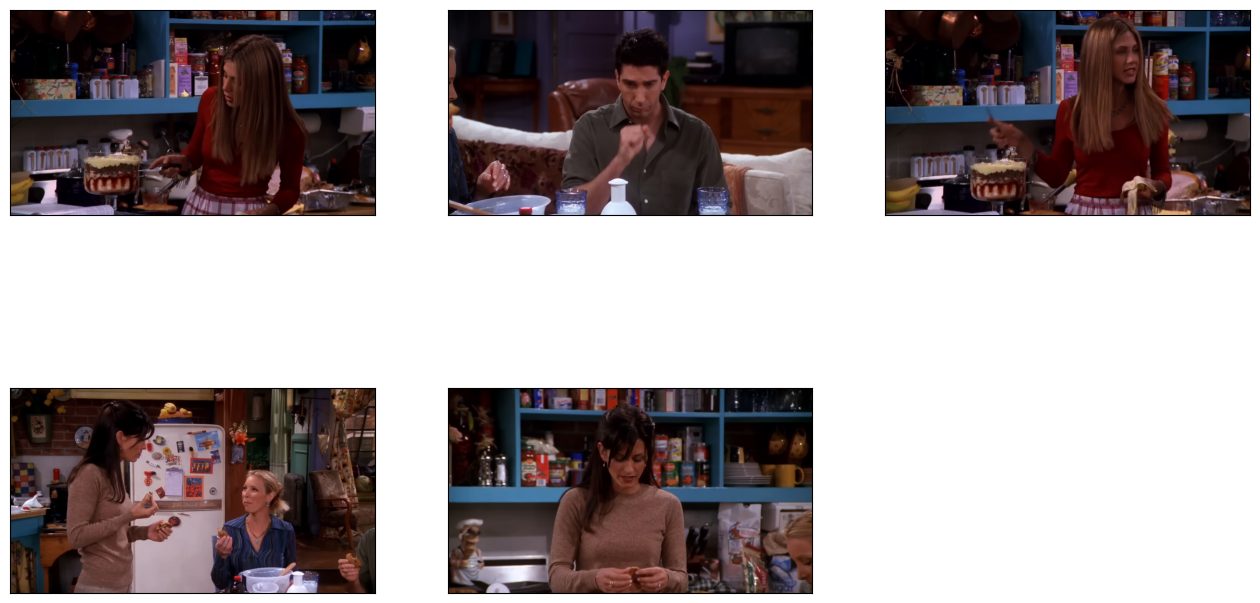

In [16]:
query_str = "tell me what dessert is included in this video"

img, txt = retrieve(retriever_engine=retriever_engine, query_str=query_str)
image_documents = SimpleDirectoryReader(input_dir=output_folder, input_files=img).load_data()
context_str = "".join(txt)
plot_images(img)
print(txt)

## Generate final response using VLM

[back to top ⬆️](#Table-of-contents:)

### Set the RAG prompt template

[back to top ⬆️](#Table-of-contents:)

In [17]:
qa_tmpl_str = (
    "Given the provided information, including relevant images and retrieved context from the video, \
 accurately and precisely answer the query without any additional prior knowledge.\n"
    "Please ensure honesty and responsibility, refraining from any racist or sexist remarks.\n"
    "---------------------\n"
    "Context: {context_str}\n"
    "---------------------\n"
    "Query: {query_str}\n"
    "Answer: "
)

### Initialize VLM

[back to top ⬆️](#Table-of-contents:)

Select inference device

In [18]:
vlm_device = device_widget(default="AUTO", exclude=["NPU"])

vlm_device

Dropdown(description='Device:', index=2, options=('CPU', 'GPU', 'AUTO'), value='AUTO')

`OpenVINOMultiModal` class provides convenient way for running multimodal model in LlamaIndex. It accepts directory with converted model and inference device as arguments. For running model with streaming we will use `stream_complete` method. For more information about the OpenVINO multimodal models support in LlamaIndex, refer to the [OpenVINOMultiModal Document](https://docs.llamaindex.ai/en/stable/examples/multi_modal/openvino_multimodal/).

In [19]:
from transformers import AutoProcessor, AutoTokenizer

vlm_int4_model_path = str(vlm_model_path)

processor = AutoProcessor.from_pretrained(vlm_int4_model_path, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained(vlm_int4_model_path)


def messages_to_prompt(messages, image_documents):
    """
    Prepares the input messages and images.
    """
    images = []
    placeholder = ""

    for i, img_doc in enumerate(image_documents, start=1):
        images.append(Image.open(img_doc.image_path))
        placeholder += f"<|image_{i}|>\n"
    conversation = [
        {"role": "user", "content": placeholder + messages[0].content},
    ]

    prompt = tokenizer.apply_chat_template(conversation, tokenize=False, add_generation_prompt=True)

    inputs = processor(prompt, images, return_tensors="pt")
    return inputs

In [20]:
from llama_index.multi_modal_llms.openvino import OpenVINOMultiModal

vlm = OpenVINOMultiModal(
    model_id_or_path=vlm_int4_model_path,
    device=vlm_device.value,
    messages_to_prompt=messages_to_prompt,
    trust_remote_code=True,
    generate_kwargs={"do_sample": False, "eos_token_id": processor.tokenizer.eos_token_id},
)

In [21]:
response = vlm.stream_complete(
    prompt=qa_tmpl_str.format(context_str=context_str, query_str=query_str),
    image_documents=image_documents,
)
for r in response:
    print(r.delta, end="")

The desserts included in the video is a trifle, which has layers of lady fingers, jam, custard, raspberries, sauteed with peas and onions, more custard, bananas, and whipped cream top.

## Interactive Demo
[back to top ⬆️](#Table-of-contents:)

Now, you can try to chat with model. Upload video, provide your text message into `Input` field and click `Submit` to start communication.

In [22]:
import gradio as gr
import base64


def path2base64(path):
    with open(path, "rb") as f:
        byte_data = f.read()
    base64_str = base64.b64encode(byte_data).decode("ascii")
    return base64_str


def build_index(video_path):
    """
    callback function for building index of vector store

    Params:
      video_path: path of uploaded video file
    Returns:
      vector store is ready

    """

    global retriever_engine
    progress = gr.Progress()
    progress(None, desc="Video to Images...")
    video_to_images(video_path, output_folder)
    progress(None, desc="Video to Audio...")
    video_to_audio(video_path, output_audio_path)
    progress(None, desc="Audio to Texts...")
    text_data = audio_to_text(output_audio_path)

    with open(output_folder + "output_text.txt", "w") as file:
        file.write(text_data)
    print("Text data saved to file")
    file.close()
    os.remove(output_audio_path)

    progress(0, desc="Building Index...")
    documents = SimpleDirectoryReader(output_folder).load_data()
    client = qdrant_client.QdrantClient(":memory:")

    text_store = QdrantVectorStore(client=client, collection_name="text_collection")
    image_store = QdrantVectorStore(client=client, collection_name="image_collection")
    storage_context = StorageContext.from_defaults(vector_store=text_store, image_store=image_store)
    index = MultiModalVectorStoreIndex.from_documents(
        documents, storage_context=storage_context, image_embed_model=Settings.embed_model, transformations=[SentenceSplitter(chunk_size=300, chunk_overlap=30)]
    )

    retriever_engine = index.as_retriever(similarity_top_k=2, image_similarity_top_k=5)
    return "Vector Store is Ready"


def search(history):
    """
    callback function for searching vector store

    Params:
      history: conversation history
    Returns:
      lists of retrieved images and texts

    """
    progress = gr.Progress()
    progress(None, desc="Searching...")
    img, txt = retrieve(retriever_engine=retriever_engine, query_str=history[-1][0])
    return img, txt


def generate(history, images, texts):
    """
    callback function for running chatbot on submit button click

    Params:
      history: conversation history
      images: list of retrieved images
      texts: list of retrieved texts

    """
    progress = gr.Progress()
    progress(None, desc="Generating...")
    image_documents = SimpleDirectoryReader(input_dir=output_folder, input_files=images).load_data()

    context_str = "".join(texts)

    response = vlm.stream_complete(
        prompt=qa_tmpl_str.format(context_str=context_str, query_str=history[-1][0]),
        image_documents=image_documents,
    )
    images_list = ""
    for image in images:
        image_base64 = path2base64(image)
        images_list += f'<img src="data:image/png;base64,{image_base64}">'
    images_list += "\n"
    partial_text = "According to audio and following screenshots from the video: \n"
    partial_text += images_list
    for r in response:
        partial_text += r.delta
        history[-1][1] = partial_text
        yield history


def stop():
    vlm._model.request.cancel()

In [23]:
if not Path("gradio_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/notebooks/multimodal-rag/gradio_helper.py")
    open("gradio_helper.py", "w").write(r.text)

from gradio_helper import make_demo

demo = make_demo(filepath, build_index, search, generate, stop)

#try:
    #demo.queue(debug=True)
#except Exception:
    #demo.queue().launch(share=True, debug=True)
# if you are launching remotely, specify server_name and server_port
# demo.launch(server_name='your server name', server_port='server port in int')
# Read more in the docs: https://gradio.app/docs/

C:\Users\yoyow\openvino_env\lib\site-packages\gradio\components\chatbot.py:285: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  warnings.warn(
C:\Users\yoyow\openvino_env\lib\site-packages\gradio\utils.py:1017: UserWarning: Expected 3 arguments for function <function generate at 0x000001FA05130B80>, received 4.
  warnings.warn(
C:\Users\yoyow\openvino_env\lib\site-packages\gradio\utils.py:1025: UserWarning: Expected maximum 3 arguments for function <function generate at 0x000001FA05130B80>, received 4.
  warnings.warn(


In [37]:
# === Cell 0: Imports and Utility Functions ===
import re
import asyncio
import gradio as gr
from tools import ShoppingCart

# Handler to append user messages to chat history
def _handle_user_message(message, history):
    return "", history + [(message, None)]

# Function to reset chat and clear cart
def _reset_chat():
    ShoppingCart.clear_cart()
    # Reset message input, chat history, log window, and cart display
    return "", [], "### Logs", render_cart()

# Helper to render cart contents as Markdown
def render_cart():
    items = ShoppingCart.get_cart_items()
    if not items:
        return "### 🛒 Your Shopping Cart is Empty"
    md = "### 🛒 Your Shopping Cart\n\n"
    for i in items:
        md += f"- {i['product_name']} x{i['quantity']} = ${i['total_price']:.2f}\n"
    return md

In [38]:
# === Cell 1: Start MCP Server ===
import threading
from mcp.server.fastmcp import FastMCP

# store the last search results globally for pricing lookups
globals_ = globals()
if 'last_search_results' not in globals_:
    last_search_results = []  # list of dicts with keys id,name,price,image
    globals_['last_search_results'] = last_search_results

if 'mcp_tool_app' not in globals_:
    mcp_tool_app = FastMCP()

    @mcp_tool_app.tool(name="search_products", description="Search products from an online store")
    def search_products(query: str) -> list:
        # TODO: integrate real e-commerce API
        results = [
            {"id": "prod_123", "name": "Gadget Pro", "price": 49.99, "image": "https://.../img1.png"},
            {"id": "prod_456", "name": "Widget Max", "price": 79.99, "image": "https://.../img2.png"},
        ]
        # cache results for add_to_cart pricing
        last_search_results.clear()
        last_search_results.extend(results)
        return results

    @mcp_tool_app.tool(name="add_to_cart", description="Add an item to the shopping cart")
    def add_to_cart(product_name: str, quantity: int = 1) -> dict:
        # look up price from last search
        price = next((item['price'] for item in last_search_results if item['name'] == product_name), 0.0)
        # ShoppingCart.add_to_cart expects (name, qty, price)
        return ShoppingCart.add_to_cart(product_name, quantity, price)

    def _run_mcp_server():
        mcp_tool_app.run(transport="streamable-http")

    threading.Thread(target=_run_mcp_server, daemon=True).start()
    print("MCP server running at http://127.0.0.1:8000/mcp")
else:
    print("MCP server already running.")

MCP server already running.


In [39]:
# === Cell 2: Initialize MCP Client ===
import nest_asyncio; nest_asyncio.apply()
import asyncio
from langchain_mcp_adapters.client import MultiServerMCPClient

tool_config = {"local": {"url": "http://127.0.0.1:8000/mcp", "transport": "streamable_http"}}
async def init_tools():
    client = MultiServerMCPClient(tool_config)
    return await client.get_tools()
tools_list = asyncio.get_event_loop().run_until_complete(init_tools())
search_products_tool = next(t for t in tools_list if t.name == "search_products")
add_to_cart_tool     = next(t for t in tools_list if t.name == "add_to_cart")


[05/22/25 12:57:43] INFO     Connecting to StreamableHTTP endpoint:                          ]8;id=394335;file://C:\Users\yoyow\openvino_env\lib\site-packages\mcp\client\streamable_http.py\streamable_http.py]8;;\:]8;id=394696;file://C:\Users\yoyow\openvino_env\lib\site-packages\mcp\client\streamable_http.py#461\461]8;;\
                             http://127.0.0.1:8000/mcp                                                             

                    INFO     HTTP Request: POST http://127.0.0.1:8000/mcp "HTTP/1.1 307 Temporary   ]8;id=92923;file://C:\Users\yoyow\openvino_env\lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=862022;file://C:\Users\yoyow\openvino_env\lib\site-packages\httpx\_client.py#1740\1740]8;;\
                             Redirect"                                                                             

                    INFO     Created new transport with session ID:                  ]8;id=43108;file://C:\Users\yoyow\openvino_env\lib\site-packages\mcp\server\streamable_http_manager.py\streamable_http_manager.py]8;;\:]8;id=353291;file://C:\Users\yoyow\openvino_env\lib\site-packages\mcp\server\streamable_http_manager.py#229\229]8;;\
                             3051b2f2db7d4b5aa6ba62cf6ad033e9                                                      

                    INFO     HTTP Request: POST http://127.0.0.1:8000/mcp/ "HTTP/1.1 200 OK"        ]8;id=981188;file://C:\Users\yoyow\openvino_env\lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=81727;file://C:\Users\yoyow\openvino_env\lib\site-packages\httpx\_client.py#1740\1740]8;;\

                    INFO     Received session ID: 3051b2f2db7d4b5aa6ba62cf6ad033e9           ]8;id=948882;file://C:\Users\yoyow\openvino_env\lib\site-packages\mcp\client\streamable_http.py\streamable_http.py]8;;\:]8;id=83668;file://C:\Users\yoyow\openvino_env\lib\site-packages\mcp\client\streamable_http.py#137\137]8;;\

...

                    INFO     Processing request of type ListToolsRequest                              ]8;id=884453;file://C:\Users\yoyow\openvino_env\lib\site-packages\mcp\server\lowlevel\server.py\server.py]8;;\:]8;id=973934;file://C:\Users\yoyow\openvino_env\lib\site-packages\mcp\server\lowlevel\server.py#551\551]8;;\

                    INFO     HTTP Request: POST http://127.0.0.1:8000/mcp/ "HTTP/1.1 200 OK"        ]8;id=626217;file://C:\Users\yoyow\openvino_env\lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=785159;file://C:\Users\yoyow\openvino_env\lib\site-packages\httpx\_client.py#1740\1740]8;;\

                    INFO     HTTP Request: DELETE http://127.0.0.1:8000/mcp "HTTP/1.1 307 Temporary ]8;id=927346;file://C:\Users\yoyow\openvino_env\lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=724970;file://C:\Users\yoyow\openvino_env\lib\site-packages\httpx\_client.py#1740\1740]8;;\
                             Redirect"                                                                             

                    INFO     Terminating session: 3051b2f2db7d4b5aa6ba62cf6ad033e9           ]8;id=128892;file://C:\Users\yoyow\openvino_env\lib\site-packages\mcp\server\streamable_http.py\streamable_http.py]8;;\:]8;id=643799;file://C:\Users\yoyow\openvino_env\lib\site-packages\mcp\server\streamable_http.py#661\661]8;;\

                    INFO     HTTP Request: DELETE http://127.0.0.1:8000/mcp/ "HTTP/1.1 200 OK"      ]8;id=412300;file://C:\Users\yoyow\openvino_env\lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=782561;file://C:\Users\yoyow\openvino_env\lib\site-packages\httpx\_client.py#1740\1740]8;;\

In [44]:
# === Cell 3: Async Response Handler with MCP Tool Calls ===
import re
import asyncio

def _generate_response(chat_history, log_history, image_list, txt_list):
    """
    Signature: (chat_history, log_history, image_list, txt_list)
    Returns: (chat_history, joined_log_str, cart_markdown)
    """
    # Prepare log list
    lh = list(log_history or [])
    logs = []

    user_msg = chat_history[-1][0].strip()
    msg_lower = user_msg.lower()

    # 1) PRODUCT SEARCH VIA MCP (match anywhere)
    if "search" in msg_lower:
        # Extract query after "search" / "search for"
        m = re.search(r"search(?: for)?\s+(.+)", user_msg, flags=re.IGNORECASE)
        query = m.group(1).strip() if m else user_msg
        logs.append(f"🔍 Searching products for: {query}")

        results = asyncio.get_event_loop().run_until_complete(
            search_products_tool.ainvoke({"query": query})
        )
        # Cache for add-to-cart lookups
        globals().setdefault("last_search_results", []).clear()
        globals()["last_search_results"].extend(results)

        # Build chat reply
        resp = "### 🔎 Search Results\n\n"
        for item in results:
            if isinstance(item, dict):
                if item.get("image"):
                    resp += f"![]({item['image']})\n"
                name = item.get("name", "<unknown>")
                price = item.get("price")
                if price is not None:
                    resp += f"**{name}** – ${price:.2f}\n\n"
                else:
                    resp += f"**{name}**\n\n"
            else:
                resp += f"- {item}\n"
        chat_history[-1][1] = resp
        return chat_history, "\n".join(lh + logs), render_cart()

    # 2) ADD TO CART VIA MCP
    if msg_lower.startswith("add"):
        parts = user_msg.split()
        qty = int(parts[1]) if len(parts) > 1 and parts[1].isdigit() else 1
        prod = " ".join(parts[2:]) if len(parts) > 2 else parts[-1]
        logs.append(f"🛒 Adding to cart: {prod} x{qty}")

        res = asyncio.get_event_loop().run_until_complete(
            add_to_cart_tool.ainvoke({"product_name": prod, "quantity": qty})
        )
        chat_history[-1][1] = res.get("message", str(res))
        return chat_history, "\n".join(lh + logs), render_cart()

    # 3) VIEW CART
    if "view cart" in msg_lower:
        logs.append("🛍️ Viewing cart contents")
        chat_history[-1][1] = "Here is your cart:"
        return chat_history, "\n".join(lh + logs), render_cart()

    # 4) CLEAR CART
    if "clear cart" in msg_lower:
        logs.append("⚠️ Clearing cart")
        ShoppingCart.clear_cart()
        chat_history[-1][1] = "Your cart has been emptied."
        return chat_history, "\n".join(lh + logs), render_cart()

    # 5) FALLBACK: VIDEO RAG + VLM
    logs.append("💬 No tool trigger – using video RAG + VLM")
    # **USE THE PASSED-IN SEARCH RESULTS** instead of calling search(user_msg)
    imgs, texts = image_list, txt_list
    # Invoke your original VLM generation
    res_list = list(generate(chat_history, imgs, texts))
    if res_list:
        chat_history = res_list[-1]
    return chat_history, "\n".join(lh + logs), render_cart()

In [45]:
# === Cell 4: Launch the Gradio demo (with video RAG + MCP agentic workflow) ===
from gradio_helper import make_demo

# `filepath`, `build_index`, `search`, and `stop` all come from your original notebook;
# _generate_response is our MCP-aware run function.
demo = make_demo(
    filepath,            # the path to your video
    build_index,         # the function that loads & indexes your video frames
    search,              # the function that does RAG retrieval on video + transcript
    _generate_response,  # now this mixes in MCP tool calls when you say "search ..." or "add ..."
    stop                 # your original stop/cancel function
)

demo.queue().launch(share=True)




C:\Users\yoyow\openvino_env\lib\site-packages\gradio\components\chatbot.py:285: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  warnings.warn(


[05/22/25 13:18:34] INFO     HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK" ]8;id=562981;file://C:\Users\yoyow\openvino_env\lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=317822;file://C:\Users\yoyow\openvino_env\lib\site-packages\httpx\_client.py#1025\1025]8;;\

* Running on local URL:  http://127.0.0.1:7866


[05/22/25 13:18:35] INFO     HTTP Request: GET http://127.0.0.1:7866/gradio_api/startup-events      ]8;id=646304;file://C:\Users\yoyow\openvino_env\lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=216317;file://C:\Users\yoyow\openvino_env\lib\site-packages\httpx\_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

                    INFO     HTTP Request: HEAD http://127.0.0.1:7866/ "HTTP/1.1 200 OK"            ]8;id=211906;file://C:\Users\yoyow\openvino_env\lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=186650;file://C:\Users\yoyow\openvino_env\lib\site-packages\httpx\_client.py#1025\1025]8;;\

...

{'video_found': True, 'audio_found': True, 'metadata': {'COMPATIBLE_BRANDS': 'iso6mp41', 'MAJOR_BRAND': 'dash', 'MINOR_VERSION': '0', 'ENCODER': 'Lavf61.7.100'}, 'inputs': [{'streams': [{'input_number': 0, 'stream_number': 0, 'stream_type': 'video', 'language': None, 'default': True, 'size': [1920, 1080], 'bitrate': None, 'fps': 23.976023976023978, 'codec_name': 'vp9', 'profile': '(Profile 0)', 'metadata': {'Metadata': '', 'HANDLER_NAME': 'ISO Media file produced by Google Inc. Created on: 05/13/2025.', 'VENDOR_ID': '[0][0][0][0]', 'DURATION': '00:07:19.396000000'}}, {'input_number': 0, 'stream_number': 1, 'stream_type': 'audio', 'language': 'eng', 'default': True, 'fps': 48000, 'bitrate': None, 'metadata': {'Metadata': '', 'DURATION': '00:07:19.428000000'}}], 'input_number': 0}], 'duration': 439.43, 'bitrate': 2486, 'start': 0.0, 'default_video_input_number': 0, 'default_video_stream_number': 0, 'video_codec_name': 'vp9', 'video_profile': '(Profile 0)', 'video_size': [1920, 1080], 'vi

MoviePy - Done.
Text data saved to file


**Node ID:** 3a4cb923-6ca9-40e4-af0c-82bf80c397a5<br>**Similarity:** 0.5683634810807604<br>**Text:** Braverman is going to send away for a free one. And that way, we all win. The only losers are the big cheesecake conglomerate Mama's Little Bakery. I feel terrible. I'm a horrible, horrible, horrib...<br>

**Node ID:** b749c0e3-ca4c-4527-8298-48c426695486<br>**Similarity:** 0.5457842772257249<br>**Text:** Joey doesn't share food. Oh, oh. Oh. Oh. Rach, you're killing us here. Will you serve the dessert already? There's drunken dancers are waiting. Look at it. Isn't it beautiful? Yeah. Yeah. What is i...<br>

Traceback (most recent call last):
  File "C:\Users\yoyow\openvino_env\lib\site-packages\gradio\queueing.py", line 625, in process_events
    response = await route_utils.call_process_api(
  File "C:\Users\yoyow\openvino_env\lib\site-packages\gradio\route_utils.py", line 322, in call_process_api
    output = await app.get_blocks().process_api(
  File "C:\Users\yoyow\openvino_env\lib\site-packages\gradio\blocks.py", line 2096, in process_api
    result = await self.call_function(
  File "C:\Users\yoyow\openvino_env\lib\site-packages\gradio\blocks.py", line 1643, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
  File "C:\Users\yoyow\openvino_env\lib\site-packages\anyio\to_thread.py", line 56, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
  File "C:\Users\yoyow\openvino_env\lib\site-packages\anyio\_backends\_asyncio.py", line 2461, in run_sync_in_worker_thread
    return await future
  File "C:\Python310\lib\asyncio\futures.p